強制重新掛載 Google Drive

In [1]:
from google.colab import drive
# force_remount=True 會強制清除舊的錯誤連結，重新要求授權
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


確認正確的檔名

In [2]:
# 列出 Skin_Project 資料夾底下的所有檔案
!ls -l "/content/drive/MyDrive/Skin_Project"

total 3143304
drwx------ 2 root root       4096 May 10 02:13 converted_labels
-rw------- 1 root root  304105990 May  9 16:08 test.zip.zip
-rw------- 1 root root 2293560934 May  9 16:23 train.zip.zip
-rw------- 1 root root  621071076 May  9 16:25 valid.zip.zip


解壓縮

In [3]:
# 1. 建立 Colab 本機儲存圖片的資料夾
!mkdir -p /content/skin_dataset

# 2. 解壓縮 train (指向 train.zip.zip)
!unzip -o "/content/drive/MyDrive/Skin_Project/train.zip.zip" -d /content/skin_dataset/train

# 3. 解壓縮 valid (指向 valid.zip.zip)
!unzip -o "/content/drive/MyDrive/Skin_Project/valid.zip.zip" -d /content/skin_dataset/valid

# 4. 解壓縮 test (指向 test.zip.zip)
!unzip -o "/content/drive/MyDrive/Skin_Project/test.zip.zip" -d /content/skin_dataset/test

# 5. 複製標籤資料夾到本機
!cp -rf "/content/drive/MyDrive/Skin_Project/converted_labels" /content/skin_dataset/labels

Archive:  /content/drive/MyDrive/Skin_Project/train.zip.zip
   creating: /content/skin_dataset/train/train.jpg/
  inflating: /content/skin_dataset/train/train.jpg/ISIC_0000000_JPG_jpg.rf.a37ba87b98e3f2bc55d0b13101388686.jpg  
  inflating: /content/skin_dataset/train/train.jpg/ISIC_0000001_JPG_jpg.rf.57c4e105b469aa775e5256427da92841.jpg  
  inflating: /content/skin_dataset/train/train.jpg/ISIC_0000004_JPG.rf.826431e099e0495934a82e51a9d48594.jpg  
  inflating: /content/skin_dataset/train/train.jpg/ISIC_0000005_JPG_jpg.rf.5548377be9f8236c631087dce0b9f480.jpg  
  inflating: /content/skin_dataset/train/train.jpg/ISIC_0000007_JPG_jpg.rf.e23ca56198835e9dfdcc9a6556d99e7c.jpg  
  inflating: /content/skin_dataset/train/train.jpg/ISIC_0000009_JPG_jpg.rf.f06a655b567da55cf942c9fc5cea93f9.jpg  
  inflating: /content/skin_dataset/train/train.jpg/ISIC_0000011_JPG_jpg.rf.01935bba403a5d85a0135226f13704ba.jpg  
  inflating: /content/skin_dataset/train/train.jpg/ISIC_0000012_JPG_jpg.rf.14daec75f380f3a0d7f

建立Dataset、DataLoader

In [4]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# 1. 定義類別字典（Nevus, Melanoma, BasalCellCarcinoma）
class_to_idx = {
    'Nevus': 0,
    'Melanoma': 1,
    'BasalCellCarcinoma': 2,
    'SquamousCellCarcinoma': 3
}
idx_to_class = {v: k for k, v in class_to_idx.items()}

# 2. 自訂 Dataset 類別
class SkinDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['filename']
        label_name = self.df.iloc[idx]['label']

        # 組合圖片路徑
        img_path = os.path.join(self.img_dir, img_name)

        # 讀取圖片
        image = Image.open(img_path).convert('RGB')

        # 轉換標籤為數字
        label = class_to_idx.get(label_name, -1)
        if label == -1:
            raise ValueError(f"發現未定義的標籤: {label_name} 於圖片 {img_name}")

        label = torch.tensor(label, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

# 3. 定義影像轉換 (Transforms)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. 實例化 Dataset (★★★移除了路徑中多餘的 converted_labels ★★★)
train_dataset = SkinDataset(
    csv_file='/content/skin_dataset/labels/train_classes_processed.csv',
    img_dir='/content/skin_dataset/train/train.jpg',  # 圖片藏在 train.jpg 資料夾中
    transform=train_transform
)

valid_dataset = SkinDataset(
    csv_file='/content/skin_dataset/labels/valid_classes_processed.csv',
    img_dir='/content/skin_dataset/valid/valid.jpg',  # 圖片藏在 valid.jpg 資料夾中
    transform=val_transform
)

# 5. 建立 DataLoader (batch_size 設為 32)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# 6. 終極資料流測試！
try:
    images, labels = next(iter(train_loader))
    print("🎉 🎉 🎉 【測試成功！資料流完全暢通】 🎉 🎉 🎉")
    print("影像批次維度 (Batch_size, Channels, H, W):", images.shape)
    print("標籤批次維度:", labels.shape)
    print("前 5 個標籤數值:", labels[:5])
    print("對應類別名稱:", [idx_to_class[l.item()] for l in labels[:5]])
except Exception as e:
    print("❌ 測試失敗，請看下方報錯訊息：")
    print(e)

🎉 🎉 🎉 【測試成功！資料流完全暢通】 🎉 🎉 🎉
影像批次維度 (Batch_size, Channels, H, W): torch.Size([32, 3, 224, 224])
標籤批次維度: torch.Size([32])
前 5 個標籤數值: tensor([0, 0, 0, 2, 0])
對應類別名稱: ['Nevus', 'Nevus', 'Nevus', 'BasalCellCarcinoma', 'Nevus']


搭建 CNN 預訓練模型與訓練迴圈

Step1 : 定義模型與損失函數、優化器

In [5]:
import torch
import torch.nn as nn
import torchvision.models as models

# 1. 偵測是否有 GPU (Colab 的 T4 GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"目前使用的裝置為: {device}")

# 2. 載入預訓練的 ResNet50 模型
# 使用 weights=models.ResNet50_Weights.DEFAULT 來取代舊版的 pretrained=True
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 3. 修改最後的 Fully Connected Layer (分類器)
# ResNet50 的最後一層輸出維度是 2048，我們要將它改為 4 類
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

# 將模型送入 GPU/CPU
model = model.to(device)

# 4. 定義損失函數 (Loss Function) 與 優化器 (Optimizer)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

print("模型結構已成功修改，準備就緒！")

目前使用的裝置為: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


模型結構已成功修改，準備就緒！


Step2 : 撰寫完整的「訓練與驗證」函式

In [6]:
import time
from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        start_time = time.time()
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")

        # ==================== 訓練階段 ====================
        model.train()
        train_loss = 0.0
        train_corrects = 0
        train_total = 0

        # 使用 tqdm 顯示進度條
        for images, labels in tqdm(train_loader, desc="Training"):
            images = images.to(device)
            labels = labels.to(device)

            # 梯度歸零
            optimizer.zero_grad()

            # 前向傳播
            outputs = model(images)
            loss = criterion(outputs, labels)

            # 反向傳播與優化
            loss.backward()
            optimizer.step()

            # 統計
            _, preds = torch.max(outputs, 1)
            train_loss += loss.item() * images.size(0)
            train_corrects += torch.sum(preds == labels.data).item()
            train_total += labels.size(0)

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_corrects / train_total

        # ==================== 驗證階段 ====================
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * images.size(0)
                val_corrects += torch.sum(preds == labels.data).item()
                val_total += labels.size(0)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_corrects / val_total

        # 紀錄歷史紀錄
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        # 印出當前 Epoch 結果
        epoch_time = time.time() - start_time
        print(f"Epoch 耗時: {epoch_time:.1f}s")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")

        # 保存最佳模型權重
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), 'best_skin_model.pth')
            import os
            os.makedirs("/content/drive/MyDrive/Skin_Project", exist_ok=True)
            torch.save(model.state_dict(), "/content/drive/MyDrive/Skin_Project/best_skin_model.pth")
            print(f"🏆 發現更好的驗證準確率 ({best_val_acc:.4f})，模型權重已儲存！")

    return history

Step3 : 啟動訓練

In [7]:
# 開始訓練！設定訓練 10 個 Epoch
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10
)


--- Epoch 1/10 ---


Training: 100%|██████████| 552/552 [07:33<00:00,  1.22it/s]


Epoch 耗時: 567.3s
Train Loss: 0.3169 | Train Acc: 0.8840
Val Loss:   0.2171 | Val Acc:   0.9194
🏆 發現更好的驗證準確率 (0.9194)，模型權重已儲存！

--- Epoch 2/10 ---


Training: 100%|██████████| 552/552 [07:31<00:00,  1.22it/s]


Epoch 耗時: 564.9s
Train Loss: 0.1960 | Train Acc: 0.9267
Val Loss:   0.2021 | Val Acc:   0.9240
🏆 發現更好的驗證準確率 (0.9240)，模型權重已儲存！

--- Epoch 3/10 ---


...

Epoch 耗時: 557.9s
Train Loss: 0.0537 | Train Acc: 0.9814
Val Loss:   0.2291 | Val Acc:   0.9349

--- Epoch 9/10 ---


Training: 100%|██████████| 552/552 [07:29<00:00,  1.23it/s]


Epoch 耗時: 562.2s
Train Loss: 0.0493 | Train Acc: 0.9836
Val Loss:   0.2163 | Val Acc:   0.9397
🏆 發現更好的驗證準確率 (0.9397)，模型權重已儲存！

--- Epoch 10/10 ---


Training: 100%|██████████| 552/552 [07:20<00:00,  1.25it/s]


Epoch 耗時: 551.2s
Train Loss: 0.0470 | Train Acc: 0.9839
Val Loss:   0.2224 | Val Acc:   0.9460
🏆 發現更好的驗證準確率 (0.9460)，模型權重已儲存！


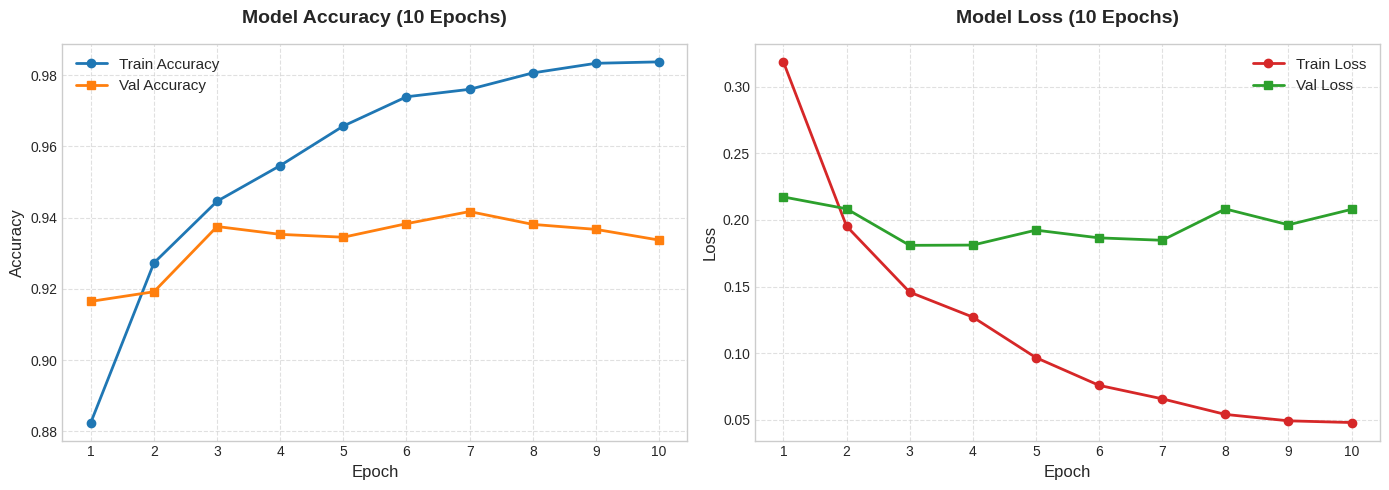

In [8]:
import matplotlib.pyplot as plt

# 根據 1 到 10 輪的螢幕輸出數值建立紀錄
manual_history = {
    'train_loss': [0.3185, 0.1953, 0.1458, 0.1271, 0.0967, 0.0759, 0.0658, 0.0541, 0.0493, 0.0480],
    'train_acc':  [0.8825, 0.9273, 0.9446, 0.9546, 0.9657, 0.9739, 0.9760, 0.9806, 0.9833, 0.9837],
    'val_loss':   [0.2172, 0.2083, 0.1809, 0.1811, 0.1923, 0.1865, 0.1847, 0.2082, 0.1963, 0.2079],
    'val_acc':    [0.9165, 0.9192, 0.9375, 0.9353, 0.9345, 0.9383, 0.9417, 0.9381, 0.9367, 0.9337]
}

# 設定畫布大小與風格
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 修改為 10 輪
epochs = range(1, 11)

# 1. 繪製 Accuracy (準確率) 曲線
ax1.plot(epochs, manual_history['train_acc'], label='Train Accuracy', color='#1f77b4', marker='o', linewidth=2)
ax1.plot(epochs, manual_history['val_acc'], label='Val Accuracy', color='#ff7f0e', marker='s', linewidth=2)
ax1.set_title('Model Accuracy (10 Epochs)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xticks(epochs)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. 繪製 Loss (損失) 曲線
ax2.plot(epochs, manual_history['train_loss'], label='Train Loss', color='#d62728', marker='o', linewidth=2)
ax2.plot(epochs, manual_history['val_loss'], label='Val Loss', color='#2ca02c', marker='s', linewidth=2)
ax2.set_title('Model Loss (10 Epochs)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_xticks(epochs)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

下載模型權重檔到本機

In [9]:
import os
drive_path = "/content/drive/MyDrive/Skin_Project/best_skin_model.pth"
if os.path.exists(drive_path):
    from google.colab import files
    files.download(drive_path)
    print("✅ 下載成功！")
else:
    print("❌ 找不到檔案，請先確認 Google Drive 已掛載並完成訓練")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 下載成功！
